In [63]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# data visualisation and manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

import tensorflow
 
#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

#preprocess.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#dl libraraies
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical
from keras.preprocessing import image

# specifically for cnn
from keras.layers import Dropout, Flatten,Activation,Lambda
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
 
import tensorflow as tf
import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
import cv2                  
import numpy as np  
from tqdm import tqdm
import os                   
from random import shuffle  
from zipfile import ZipFile
from PIL import Image

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv
/kaggle/input/files-for-digit/sample_submission.csv
/kaggle/input/files-for-digit/train.csv
/kaggle/input/files-for-digit/test.csv


In [64]:
train=pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test=pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

print(train.shape)
print(train.head())

(42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0      

In [65]:
#turn data set into array of arrays
train.head()
X_train=(train.iloc[:,1:].values).astype("float32")
X_train=X_train.reshape(X_train.shape[0],28,28,1)  #(number of pics, row pixels, columns pixels, gray)
# print(X_train)

#save label
Z_train=(train.iloc[:,0].values).astype("int32")
# print(Z_train)

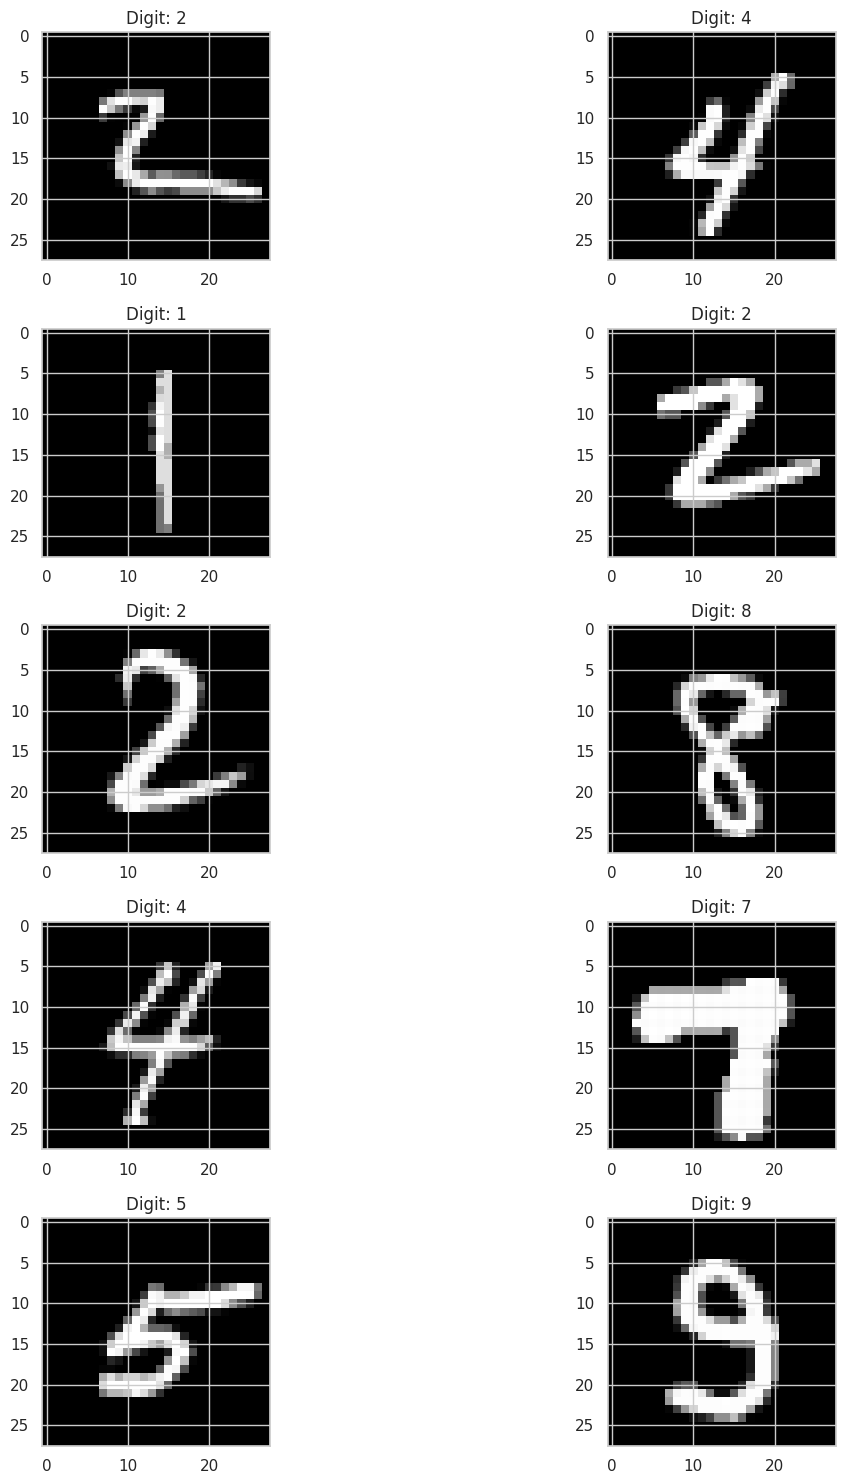

In [66]:
#print some images from train date
fig,ax=plt.subplots(5,2)
fig.set_size_inches(15,15)
for i in range(5):
    for j in range (2):
        l=rn.randint(0,len(Z_train))
        ax[i,j].imshow(X_train[l], cmap=plt.get_cmap("gray"))
        ax[i,j].set_title('Digit: '+str(Z_train[l]))
        
plt.tight_layout()

In [67]:
#save test data
X_test=test.values.astype("float32")
X_test=X_test.reshape(X_test.shape[0],28,28,1)
print(X_test.shape[0])
# print(X_test)

28000


In [68]:
le=LabelEncoder()
# Y_train=le.fit_transform(Z_train)
# print(Y_train)
Y_train=to_categorical(Z_train,10)  #one-hot vectors
print(Y_train)
print(Z_train)

[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
[1 0 1 ... 7 6 9]


In [69]:
#standardize X_train

mean_px = X_train.mean().astype(np.float32)
std_px = X_train.std().astype(np.float32)

def standardize(x): 
    return (x-mean_px)/std_px

X_train=X_train/255
print(X_train)

[[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.

In [70]:
#split training set into training and validation sets
x_train, x_val, y_train, y_val=train_test_split(X_train, Y_train, test_size=0.10, random_state=42)

In [79]:
np.random.seed(42)
rn.seed(42)
tf.random.set_seed(42)


# modelling starts using a CNN.

#figuring out lambda vs this model 

# model = Sequential()
# model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',activation ='relu', input_shape = (28,28,1)))
# model.add(MaxPooling2D(pool_size=(2,2)))


# model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',activation ='relu'))
# model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
 

# model.add(Conv2D(filters =96, kernel_size = (3,3),padding = 'Same',activation ='relu'))
# model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# # model.add(Conv2D(filters = 96, kernel_size = (3,3),padding = 'Same',activation ='relu'))
# # model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# model.add(Flatten())
# model.add(Dense(512))
# model.add(Activation('relu'))
# model.add(Dense(10, activation = "softmax"))





#lambda method
model= Sequential()
model.add(Lambda(standardize,input_shape=(28,28,1)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(10, activation='softmax'))
print("input shape ",model.input_shape)
print("output shape ",model.output_shape)
model.summary


input shape  (None, 28, 28, 1)
output shape  (None, 10)


<bound method Model.summary of <Sequential name=sequential_4, built=True>>

In [72]:
print(X_train.shape)

(42000, 28, 28, 1)


In [80]:
#Using a LearningRate Annealer
batch_size=64
epochs=8

from keras.callbacks import ReduceLROnPlateau
red_lr= ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.1)

In [74]:
#Data Augmentation to prevent overfitting!
# datagen = ImageDataGenerator(
#         featurewise_center=False,  # set input mean to 0 over the dataset
#         samplewise_center=False,  # set each sample mean to 0
#         featurewise_std_normalization=False,  # divide inputs by std of the dataset
#         samplewise_std_normalization=False,  # divide each input by its std
#         zca_whitening=False,  # apply ZCA whitening
#         rotation_range=5,  # randomly rotate images in the range (degrees, 0 to 180)
#         zoom_range = 0.1, # Randomly zoom image 
#         width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
#         height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
#         horizontal_flip=False,  # randomly flip images
#         vertical_flip=False)  # randomly flip images

# datagen.fit(x_train)



#no data generation
datagen = ImageDataGenerator()

In [85]:
#compile the Keras Model & Summary
from keras.optimizers import RMSprop
model.compile(optimizer='Adam', loss='categorical_crossentropy',
                  metrics=['accuracy'])
# model.compile(optimizer=RMSprop(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_4 (Lambda)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
#Fitting on the training set and make predictions on val set
History = model.fit(datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (x_val,y_val),
                              verbose = 1, steps_per_epoch=x_train.shape[0] // batch_size)
# History = model.fit(datagen.flow(x_train,y_train, batch_size=batch_size),
#                     epochs = epochs, validation_data = (x_val,y_val),
#                     steps_per_epoch=x_train.shape[0] )
# model.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,validation_data = (x_val,y_test))

Epoch 1/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1062 - loss: 2.3025 - val_accuracy: 0.1121 - val_loss: 2.3000
Epoch 2/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - accuracy: 0.0781 - loss: 2.3014 - val_accuracy: 0.1121 - val_loss: 2.3000
Epoch 3/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1127 - loss: 2.3013 - val_accuracy: 0.1121 - val_loss: 2.2999
Epoch 4/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.1719 - loss: 2.2967 - val_accuracy: 0.1121 - val_loss: 2.2999
Epoch 5/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1080 - loss: 2.3014 - val_accuracy: 0.1121 - val_loss: 2.2999
Epoch 6/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.0938 - loss: 2.3104 - val_accuracy: 0.1121 - val_loss: 2.2999
Epoch 7/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1102 - loss: 2.3018 - val_accuracy: 0.1121 - val_loss: 2.2998
Epoch 8/8
590/590 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.1250 - loss: 2.3061 - val_accuracy: 0.

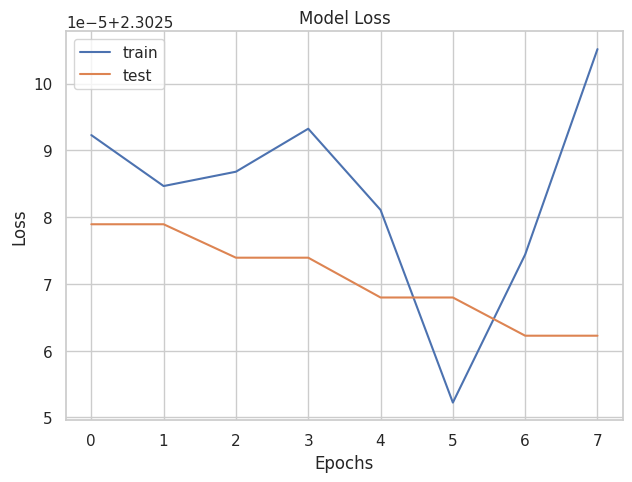

In [77]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

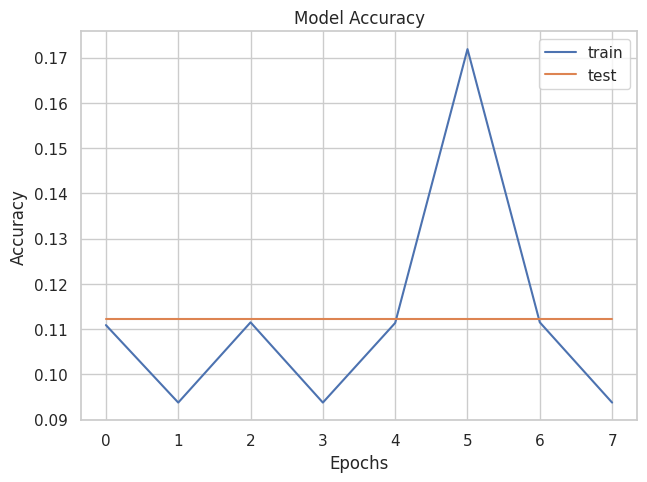

In [78]:
plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()